# CSCI E-89 Deep Learning: Assignment 03, Problem 3

**Andra Constandache**

FashionMNIST image classifier in PyTorch, following "Building an Image Classifier with PyTorch" (Geron, *Hands-On Machine Learning*, ch. 10). Each code cell below is one of the step scripts in this folder, in execution order. Imports of earlier scripts are commented out, so the notebook runs top to bottom on its own.

| Cell | Script | Purpose |
|---|---|---|
| Cell 1 | `load_data.py` | Load FashionMNIST with `transforms.v2`, split it 55,000/5,000 into train/valid with seed 42, and build DataLoaders (batch size 32). |
| Cell 2 | `model.py` | Pick the device and define the `ImageClassifier` MLP (784 -> 300 -> 100 -> 10) with `CrossEntropyLoss`. |
| Cell 3 | `train.py` | Define `evaluate_tm` and `train2`, train for 20 epochs with SGD (lr 0.1) and torchmetrics accuracy, save the weights and history. |
| Cell 4 | `plot_accuracy.py` | Plot the training accuracy per epoch and save `training_accuracy.png`. |
| Cell 5 | `predict.py` | Load the saved weights and predict 3 validation images. |


## Cell 1: `load_data.py`

Load FashionMNIST with `transforms.v2`, split it 55,000/5,000 into train/valid with seed 42, and build DataLoaders (batch size 32).

In [1]:
"""Step 1: load FashionMNIST, split it into train/valid/test, build DataLoaders.

CSCI E-89 Deep Learning, Assignment 03, Problem 3 (Andra Constandache).
Follows "Building an Image Classifier with PyTorch" in Geron, Hands-On
Machine Learning, chapter 10 (10_neural_nets_with_pytorch.ipynb).
"""

import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

# Preprocessing pipeline, as in Geron:
# ToImage() turns each PIL image into an image tensor of shape [1, 28, 28]
# (channels, height, width) with uint8 pixels in 0-255.
# ToDtype(float32, scale=True) casts to float32 and rescales pixels to [0, 1].
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Load FashionMNIST (downloaded into ./datasets on the first run).
# The official training set has 60,000 images, the test set 10,000.
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

# Split the training set into 55,000 train and 5,000 validation images.
# Seeding first makes random_split produce the same split on every run.
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

# Wrap each dataset in a DataLoader serving mini-batches of 32 images.
# Geron re-seeds here so the training loader's shuffle order is reproducible.
# Only the training data is shuffled (a new order each epoch).
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

if __name__ == "__main__":
    # Dataset sizes: expected 55,000 / 5,000 / 10,000.
    print(f"Train size: {len(train_data)}")
    print(f"Valid size: {len(valid_data)}")
    print(f"Test size:  {len(test_data)}")

    # One sample is an (image, target) tuple. Grayscale, so shape [1, 28, 28].
    X_sample, y_sample = train_data[0]
    print(f"Sample shape: {X_sample.shape}, dtype: {X_sample.dtype}")
    print(f"Sample class: {y_sample} ({train_and_valid_data.classes[y_sample]})")

    # One batch: images [32, 1, 28, 28] float32, labels [32] int64.
    X_batch, y_batch = next(iter(train_loader))
    print(f"Batch images: {X_batch.shape}, dtype: {X_batch.dtype}")
    print(f"Batch labels: {y_batch.shape}, dtype: {y_batch.dtype}")


Train size: 55000
Valid size: 5000
Test size:  10000
Sample shape: torch.Size([1, 28, 28]), dtype: torch.float32
Sample class: 9 (Ankle boot)
Batch images: torch.Size([32, 1, 28, 28]), dtype: torch.float32
Batch labels: torch.Size([32]), dtype: torch.int64


## Cell 2: `model.py`

Pick the device and define the `ImageClassifier` MLP (784 -> 300 -> 100 -> 10) with `CrossEntropyLoss`.

In [2]:
"""Step 2: pick a device and define the ImageClassifier MLP and its loss.

CSCI E-89 Deep Learning, Assignment 03, Problem 3 (Andra Constandache).
Follows "Building an Image Classifier with PyTorch" in Geron, Hands-On
Machine Learning, chapter 10 (10_neural_nets_with_pytorch.ipynb).
"""

import torch
import torch.nn as nn

# from load_data import train_loader  (defined in an earlier cell)

# Use an NVIDIA GPU (cuda) or Apple GPU (mps) if available, else the CPU.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"


# The classifier is a multilayer perceptron:
# Flatten turns each [1, 28, 28] image into a 784-value vector, two hidden
# layers (300 and 100 units, ReLU) learn features, and the output layer
# returns one raw score (logit) per class. There is no softmax at the end:
# CrossEntropyLoss applies log-softmax internally, which is more stable.
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


# Build the model (784 -> 300 -> 100 -> 10) on the chosen device.
# Seeding makes the initial weights reproducible, as in Geron.
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)

# Loss for multiclass classification with integer class labels.
xentropy = nn.CrossEntropyLoss()

if __name__ == "__main__":
    print(f"Device: {device}")
    print(model)

    # Expected: 784*300+300 + 300*100+100 + 100*10+10 = 266,610 parameters.
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params:,}")

    # One forward pass on a batch: output [32, 10] (one logit per class).
    # An untrained model should give a loss near ln(10) = 2.30 (random guess).
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    with torch.no_grad():
        y_pred = model(X_batch)
    print(f"Output shape: {y_pred.shape}")
    print(f"Initial loss: {xentropy(y_pred, y_batch).item():.4f}")


Device: cpu
ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Parameters: 266,610
Output shape: torch.Size([32, 10])
Initial loss: 2.3156


## Cell 3: `train.py`

Define `evaluate_tm` and `train2`, train for 20 epochs with SGD (lr 0.1) and torchmetrics accuracy, save the weights and history.

In [3]:
"""Step 3: train the ImageClassifier with SGD and track accuracy.

CSCI E-89 Deep Learning, Assignment 03, Problem 3 (Andra Constandache).
Uses evaluate_tm() and train2() from "Building an Image Classifier with
PyTorch" in Geron, Hands-On Machine Learning, chapter 10.
Saves the weights to fashion_mnist_mlp.pt and the history to history.json.
"""

import json

import torch
import torchmetrics

# from load_data import train_loader, valid_loader  (defined in an earlier cell)
# from model import device, model, xentropy  (defined in an earlier cell)


# Evaluate a model on a whole DataLoader with a torchmetrics metric.
# The metric accumulates counts over all batches, so the result is exact
# for the full dataset (not an average of per-batch values).
def evaluate_tm(model, data_loader, metric):
    model.eval()        # evaluation mode (no dropout/batch-norm updates)
    metric.reset()      # clear state from any earlier call
    with torch.no_grad():   # no gradients needed during evaluation
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


# Training loop: for each epoch, run mini-batch gradient descent on the
# training set, then measure the metric on the validation set.
# Returns a history dict of per-epoch train loss, train metric, valid metric.
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()   # evaluate_tm() switches to eval mode, switch back
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)             # forward pass (logits)
            loss = criterion(y_pred, y_batch)   # loss vs. true labels
            total_loss += loss.item()
            loss.backward()                     # backprop: gradients
            optimizer.step()                    # gradient descent step
            optimizer.zero_grad()               # reset gradients
            metric.update(y_pred, y_batch)      # running train accuracy
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


if __name__ == "__main__":
    # Plain SGD with learning rate 0.1, and multiclass accuracy as the metric.
    n_epochs = 20
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

    # Train for 20 epochs.
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs)

    # Save the trained weights and the history for the next scripts.
    torch.save(model.state_dict(), "fashion_mnist_mlp.pt")
    with open("history.json", "w") as f:
        json.dump(history, f, indent=2)
    print("Saved fashion_mnist_mlp.pt and history.json")


Epoch 1/20, train loss: 0.6060, train metric: 0.7783, valid metric: 0.8410


Epoch 2/20, train loss: 0.4052, train metric: 0.8498, valid metric: 0.8502


Epoch 3/20, train loss: 0.3647, train metric: 0.8642, valid metric: 0.8654


Epoch 4/20, train loss: 0.3341, train metric: 0.8752, valid metric: 0.8582


Epoch 5/20, train loss: 0.3153, train metric: 0.8826, valid metric: 0.8698


...

Epoch 16/20, train loss: 0.2084, train metric: 0.9206, valid metric: 0.8842


Epoch 17/20, train loss: 0.2016, train metric: 0.9230, valid metric: 0.8894


Epoch 18/20, train loss: 0.1966, train metric: 0.9238, valid metric: 0.8914


Epoch 19/20, train loss: 0.1935, train metric: 0.9258, valid metric: 0.8810


Epoch 20/20, train loss: 0.1865, train metric: 0.9286, valid metric: 0.8906
Saved fashion_mnist_mlp.pt and history.json


## Cell 4: `plot_accuracy.py`

Plot the training accuracy per epoch and save `training_accuracy.png`.

Epochs: 20, first: 0.7783, last: 0.9286
Saved training_accuracy.png


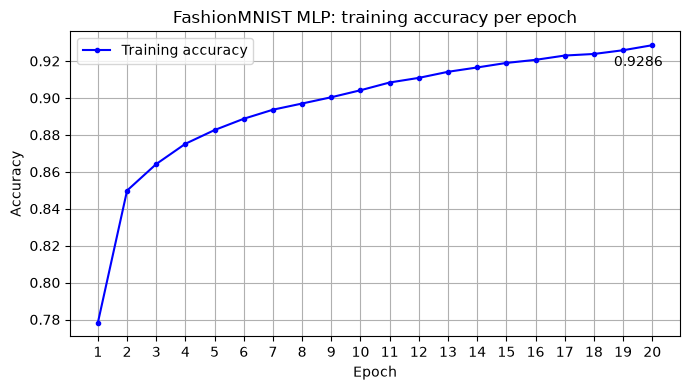

In [4]:
"""Step 4: plot the training accuracy per epoch from history.json.

CSCI E-89 Deep Learning, Assignment 03, Problem 3 (Andra Constandache).
Reads the history saved by train.py and saves training_accuracy.png.
"""

import json

import matplotlib.pyplot as plt

# Load the per-epoch history written by train.py.
with open("history.json") as f:
    history = json.load(f)

# Epoch numbers 1..n for the x-axis.
train_acc = history["train_metrics"]
epochs = range(1, len(train_acc) + 1)

# Line plot of training accuracy, with the final value labeled.
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_acc, "b.-", label="Training accuracy")
plt.annotate(f"{train_acc[-1]:.4f}", (epochs[-1], train_acc[-1]),
             textcoords="offset points", xytext=(-10, -15), ha="center")
plt.xticks(list(epochs))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST MLP: training accuracy per epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure for the report.
plt.savefig("training_accuracy.png", dpi=150)
print(f"Epochs: {len(train_acc)}, first: {train_acc[0]:.4f}, "
      f"last: {train_acc[-1]:.4f}")
print("Saved training_accuracy.png")


## Cell 5: `predict.py`

Load the saved weights and predict 3 validation images.

In [5]:
"""Step 5: load the trained weights and classify 3 validation images.

CSCI E-89 Deep Learning, Assignment 03, Problem 3 (Andra Constandache).
Follows the prediction code in "Building an Image Classifier with PyTorch"
in Geron, Hands-On Machine Learning, chapter 10.
"""

import torch
import torch.nn.functional as F

# from load_data import train_and_valid_data, valid_loader  (defined in an earlier cell)
# from model import device, model  (defined in an earlier cell)

# Load the weights saved by train.py into the ImageClassifier.
model.load_state_dict(torch.load("fashion_mnist_mlp.pt", map_location=device))

# Take the first 3 images of the (unshuffled) validation set.
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]

# Predict: the class with the highest logit wins. Softmax turns the logits
# into probabilities, so the winning probability is the model's confidence.
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()
y_proba = F.softmax(y_pred_logits, dim=1).cpu()

# Print the predicted class, confidence, and true class for each image.
class_names = train_and_valid_data.classes
for i in range(3):
    pred, true = class_names[y_pred[i]], class_names[y_new[i]]
    status = "correct" if y_pred[i] == y_new[i] else "wrong"
    print(f"Image {i + 1}: predicted {pred} ({y_proba[i, y_pred[i]]:.1%}), "
          f"true {true} ({status})")


Image 1: predicted Sneaker (99.7%), true Sneaker (correct)
Image 2: predicted Coat (99.6%), true Coat (correct)
Image 3: predicted Pullover (72.8%), true Pullover (correct)
